In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r"C:\Users\Lala\Downloads\archive\NYC.csv")

In [3]:
df

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435
...,...,...,...,...,...,...,...,...,...,...,...
1458639,id2376096,2,2016-04-08 13:31:04,2016-04-08 13:44:02,4,-73.982201,40.745522,-73.994911,40.740170,N,778
1458640,id1049543,1,2016-01-10 07:35:15,2016-01-10 07:46:10,1,-74.000946,40.747379,-73.970184,40.796547,N,655
1458641,id2304944,2,2016-04-22 06:57:41,2016-04-22 07:10:25,1,-73.959129,40.768799,-74.004433,40.707371,N,764
1458642,id2714485,1,2016-01-05 15:56:26,2016-01-05 16:02:39,1,-73.982079,40.749062,-73.974632,40.757107,N,373


In [4]:
df.shape

(1458644, 11)

In [5]:
df.isnull().sum()

id                    0
vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
dtype: int64

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  object 
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  object 
 3   dropoff_datetime    1458644 non-null  object 
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  object 
 10  trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 122.4+ MB


In [4]:
df["pickup_datetime"] = pd.to_datetime(df["pickup_datetime"])

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   id                  1458644 non-null  object        
 1   vendor_id           1458644 non-null  int64         
 2   pickup_datetime     1458644 non-null  datetime64[ns]
 3   dropoff_datetime    1458644 non-null  object        
 4   passenger_count     1458644 non-null  int64         
 5   pickup_longitude    1458644 non-null  float64       
 6   pickup_latitude     1458644 non-null  float64       
 7   dropoff_longitude   1458644 non-null  float64       
 8   dropoff_latitude    1458644 non-null  float64       
 9   store_and_fwd_flag  1458644 non-null  object        
 10  trip_duration       1458644 non-null  int64         
dtypes: datetime64[ns](1), float64(4), int64(3), object(3)
memory usage: 122.4+ MB


## Convert to minute

In [6]:
df["trip_duration_minutes"] = df["trip_duration"] / 60

## Remove outliers

In [7]:
df = df[(df["trip_duration_minutes"] >= 1) & (df["trip_duration_minutes"] <= 120)]

## Extract hour, weekday and month


In [9]:
df["hour"] = df["pickup_datetime"].dt.hour
df["day_of_week"] = df["pickup_datetime"].dt.day_name()
df["month"] = df["pickup_datetime"].dt.month_name()

C:\Users\Lala\AppData\Local\Temp\ipykernel_19576\346097475.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["hour"] = df["pickup_datetime"].dt.hour
C:\Users\Lala\AppData\Local\Temp\ipykernel_19576\346097475.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["day_of_week"] = df["pickup_datetime"].dt.day_name()
C:\Users\Lala\AppData\Local\Temp\ipykernel_19576\346097475.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_ind

In [10]:
df

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,trip_duration_minutes,hour,day_of_week,month
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455,7.583333,17,Monday,March
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663,11.050000,0,Sunday,June
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124,35.400000,11,Tuesday,January
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429,7.150000,19,Wednesday,April
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435,7.250000,13,Saturday,March
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1458639,id2376096,2,2016-04-08 13:31:04,2016-04-08 13:44:02,4,-73.982201,40.745522,-73.994911,40.740170,N,778,12.966667,13,Friday,April
1458640,id1049543,1,2016-01-10 07:35:15,2016-01-10 07:46:10,1,-74.000946,40.747379,-73.970184,40.796547,N,655,10.916667,7,Sunday,January
1458641,id2304944,2,2016-04-22 06:57:41,2016-04-22 07:10:25,1,-73.959129,40.768799,-74.004433,40.707371,N,764,12.733333,6,Friday,April
1458642,id2714485,1,2016-01-05 15:56:26,2016-01-05 16:02:39,1,-73.982079,40.749062,-73.974632,40.757107,N,373,6.216667,15,Tuesday,January


## Trip count by hour

In [11]:
hourly_trips = df.groupby("hour").size()

In [12]:
hourly_trips

hour
0     52775
1     38221
2     27661
3     20637
4     15524
5     14767
6     32933
7     55213
8     66662
9     67253
10    65032
11    68024
12    71370
13    70976
14    73697
15    71223
16    63758
17    75910
18    90022
19    89753
20    83536
21    83607
22    79936
23    69306
dtype: int64

## Peak & Off-Peak Hours

In [13]:
peak_hour = hourly_trips.idxmax()
off_peak_hour = hourly_trips.idxmin()

In [14]:
print('peak_hour:', peak_hour)

peak_hour: 18


In [15]:
print('off_peak_hour:',off_peak_hour)

off_peak_hour: 5


## Trip count by day of week

In [16]:
df.groupby('day_of_week').size()

day_of_week
Friday       221870
Monday       186051
Saturday     219190
Sunday       193669
Thursday     216947
Tuesday      201318
Wednesday    208751
dtype: int64

## Weekend vs Weekday

In [17]:
weekday=0
weekend=0
for i in df["day_of_week"]:
    if i=='Saturday' or i=='Sunday':
        weekend+=1
    else:
        weekday+=1

print('weekday:', weekday)
print('weekend:', weekend)

weekday: 1034937
weekend: 412859


## AVG Trip Duration

In [31]:
avg_trip=df.groupby('hour')['trip_duration_minutes'].mean()

In [32]:
avg_trip

hour
0     13.099148
1     12.406891
2     11.788360
3     11.809817
4     12.380970
5     12.006863
6     11.266490
7     12.703321
8     13.963393
9     14.120025
10    14.189638
11    14.659226
12    14.696227
13    15.010536
14    15.856380
15    16.164062
16    16.158841
17    15.595790
18    14.398233
19    13.222705
20    12.864063
21    12.999611
22    13.472555
23    13.607323
Name: trip_duration_minutes, dtype: float64

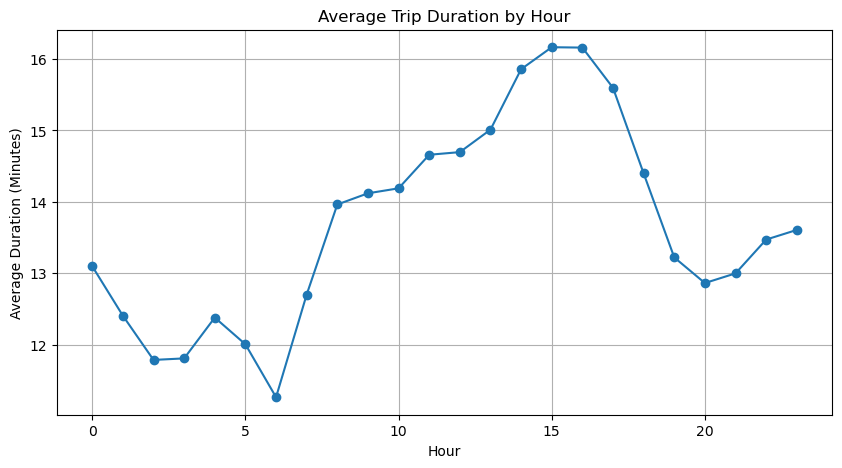

In [39]:
plt.figure(figsize=(10,5))
avg_trip.plot(marker="o")
plt.title("Average Trip Duration by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Duration (Minutes)")
plt.grid(True)


plt.show()

### Ən uzun müddətli səyahət saat 3-4 radələrində olub

## Monthly trip count

In [41]:
monthly_trips = df.groupby('month').size()

In [42]:
monthly_trips

month
April       249713
February    236609
January     228064
June        232525
March       254306
May         246579
dtype: int64

# VIZUALIZATIONS

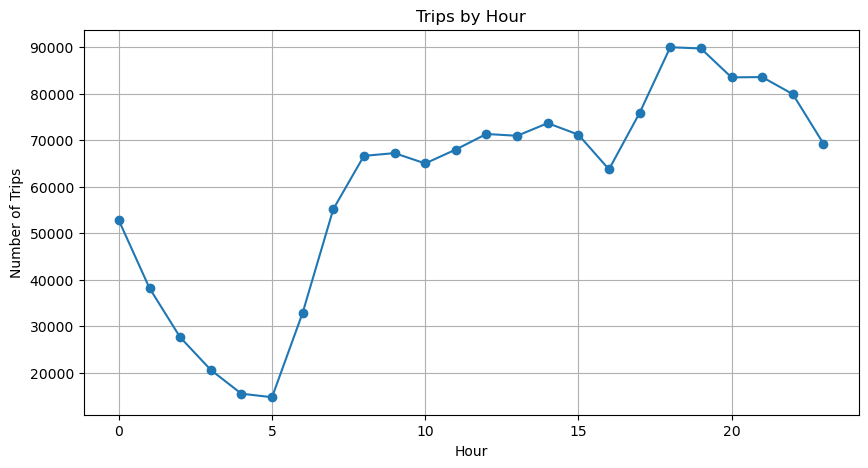

In [25]:
plt.figure(figsize=(10,5))
hourly_trips.plot(marker="o")
plt.title("Trips by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Trips")
plt.grid(True)

plt.show()

### Qrafikdən də aydın görünür ki, saat 5 radələri ən az trip sayı olan saat , saat axşam 6  radələri isə pik saatlardır

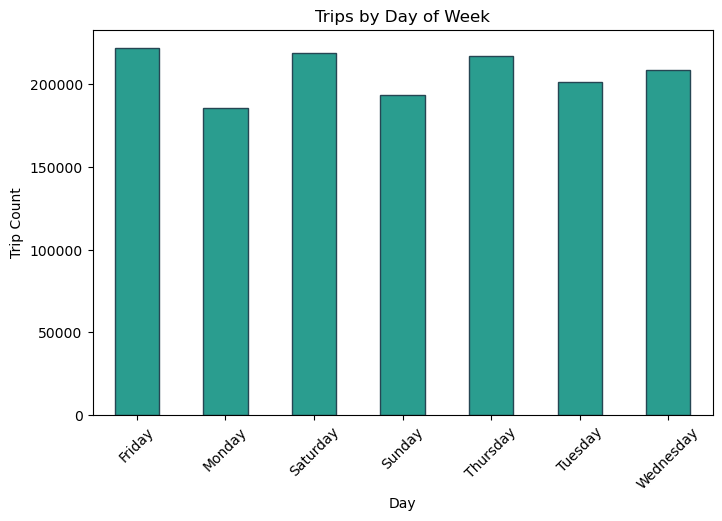

In [29]:
plt.figure(figsize=(8,5))
df.groupby('day_of_week').size().plot(kind="bar", color='#2a9d8f',edgecolor='#264653')
plt.title("Trips by Day of Week")
plt.xlabel("Day")
plt.ylabel("Trip Count")
plt.xticks(rotation=45)

plt.show()

### Həftənin cümə axşamı, cümə və şənbə günləri gəzintilər daha çox olub

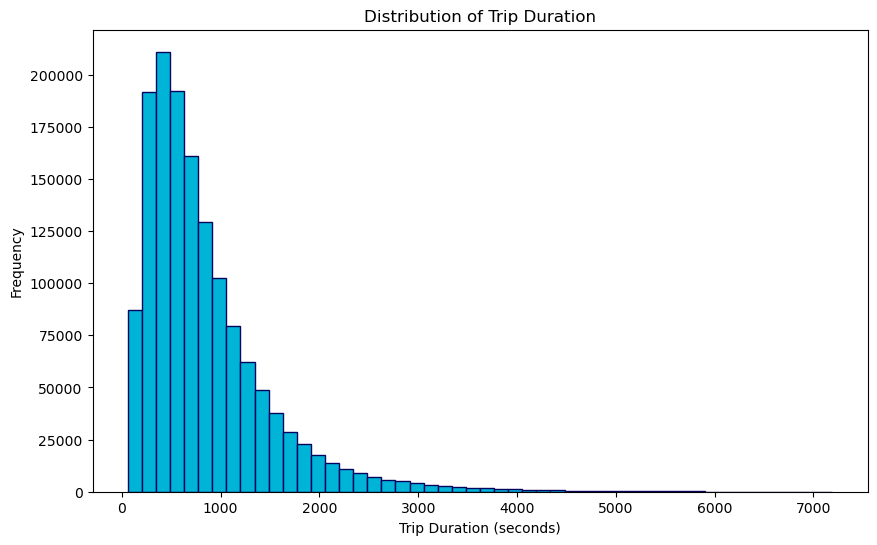

In [37]:
plt.figure(figsize=(10,6))
df['trip_duration'].plot(kind='hist', bins=50,color='#00b4d8',edgecolor='#03045e')
plt.title('Distribution of Trip Duration')
plt.xlabel('Trip Duration (seconds)')
plt.ylabel('Frequency')

plt.show()

### Qrafik paylanması sağa meyillidir. Yəni uzun müddətli səfərlər azda olsa var. Datada outlierlər var yəqinki bu hava şəraiti ilə bağlı yada uzaq məsafəylə bağlı yaranıb

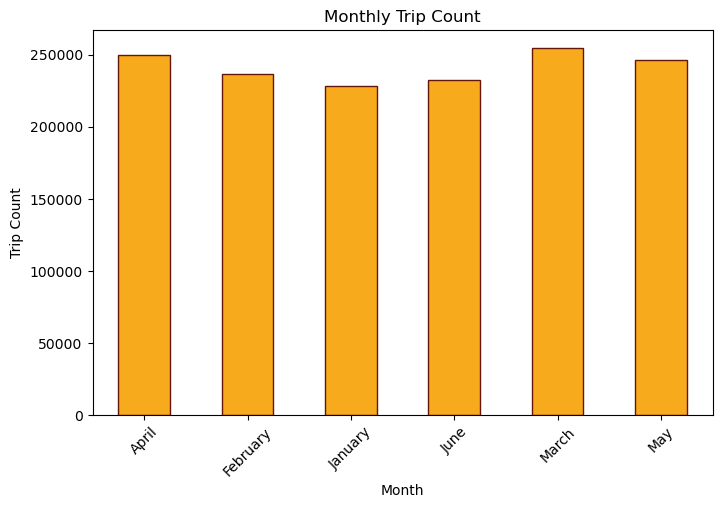

In [44]:
plt.figure(figsize=(8,5))
monthly_trips.plot(kind="bar",color='#f6aa1c',edgecolor='#621708')
plt.title("Monthly Trip Count")
plt.xlabel("Month")
plt.ylabel("Trip Count")
plt.xticks(rotation=45)

plt.show()

### Ən çox səyahət mart,may və aprel aylarına təsadüf edir. Yəqinki bu fəsil dəyişkənliyi yəni yazın gəlişi havaların isinməsi ilə əlaqəli olub